In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno

from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
import re


import matplotlib.pyplot as plt
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

## missing data no, 결측치의 패턴을 쉽게 파악할 수 있도록 하는 라이브러리

In [2]:
df = pd.read_csv('../../data/netflix_titles.csv')
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [4]:
df['cast'].isna().sum()

np.int64(718)

<Axes: >

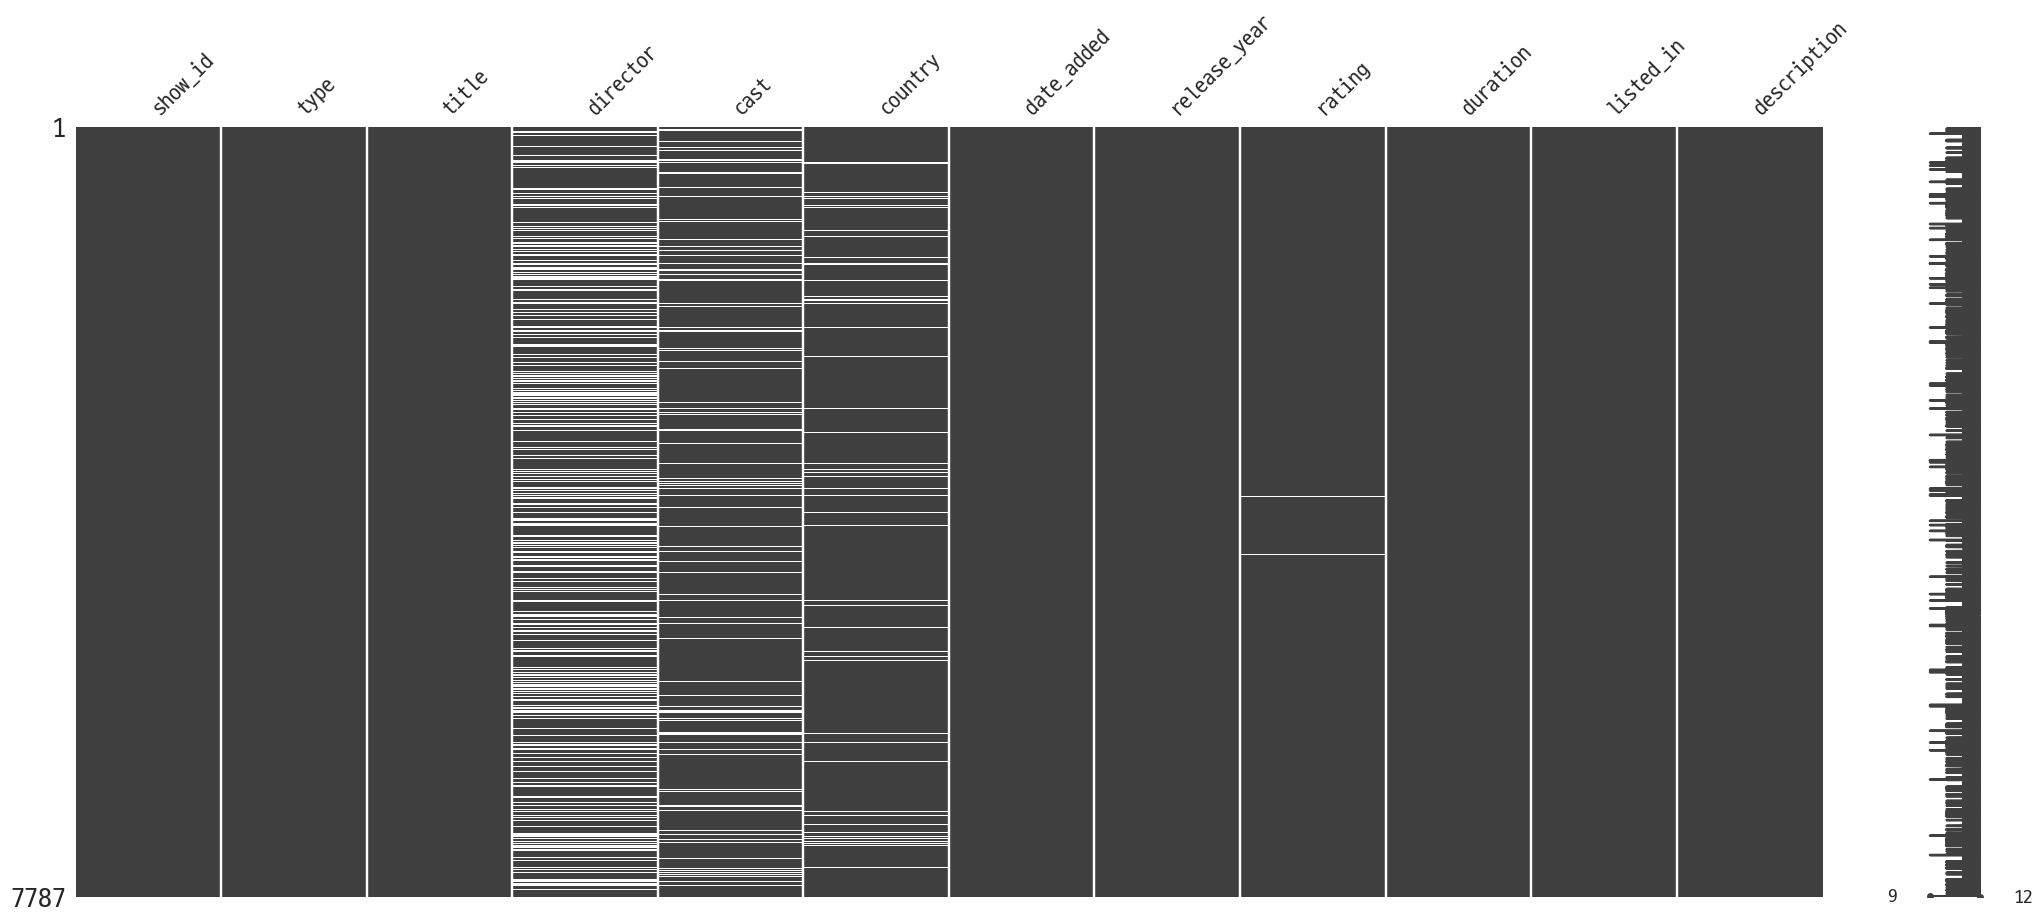

In [5]:
msno.matrix(df)

<Axes: >

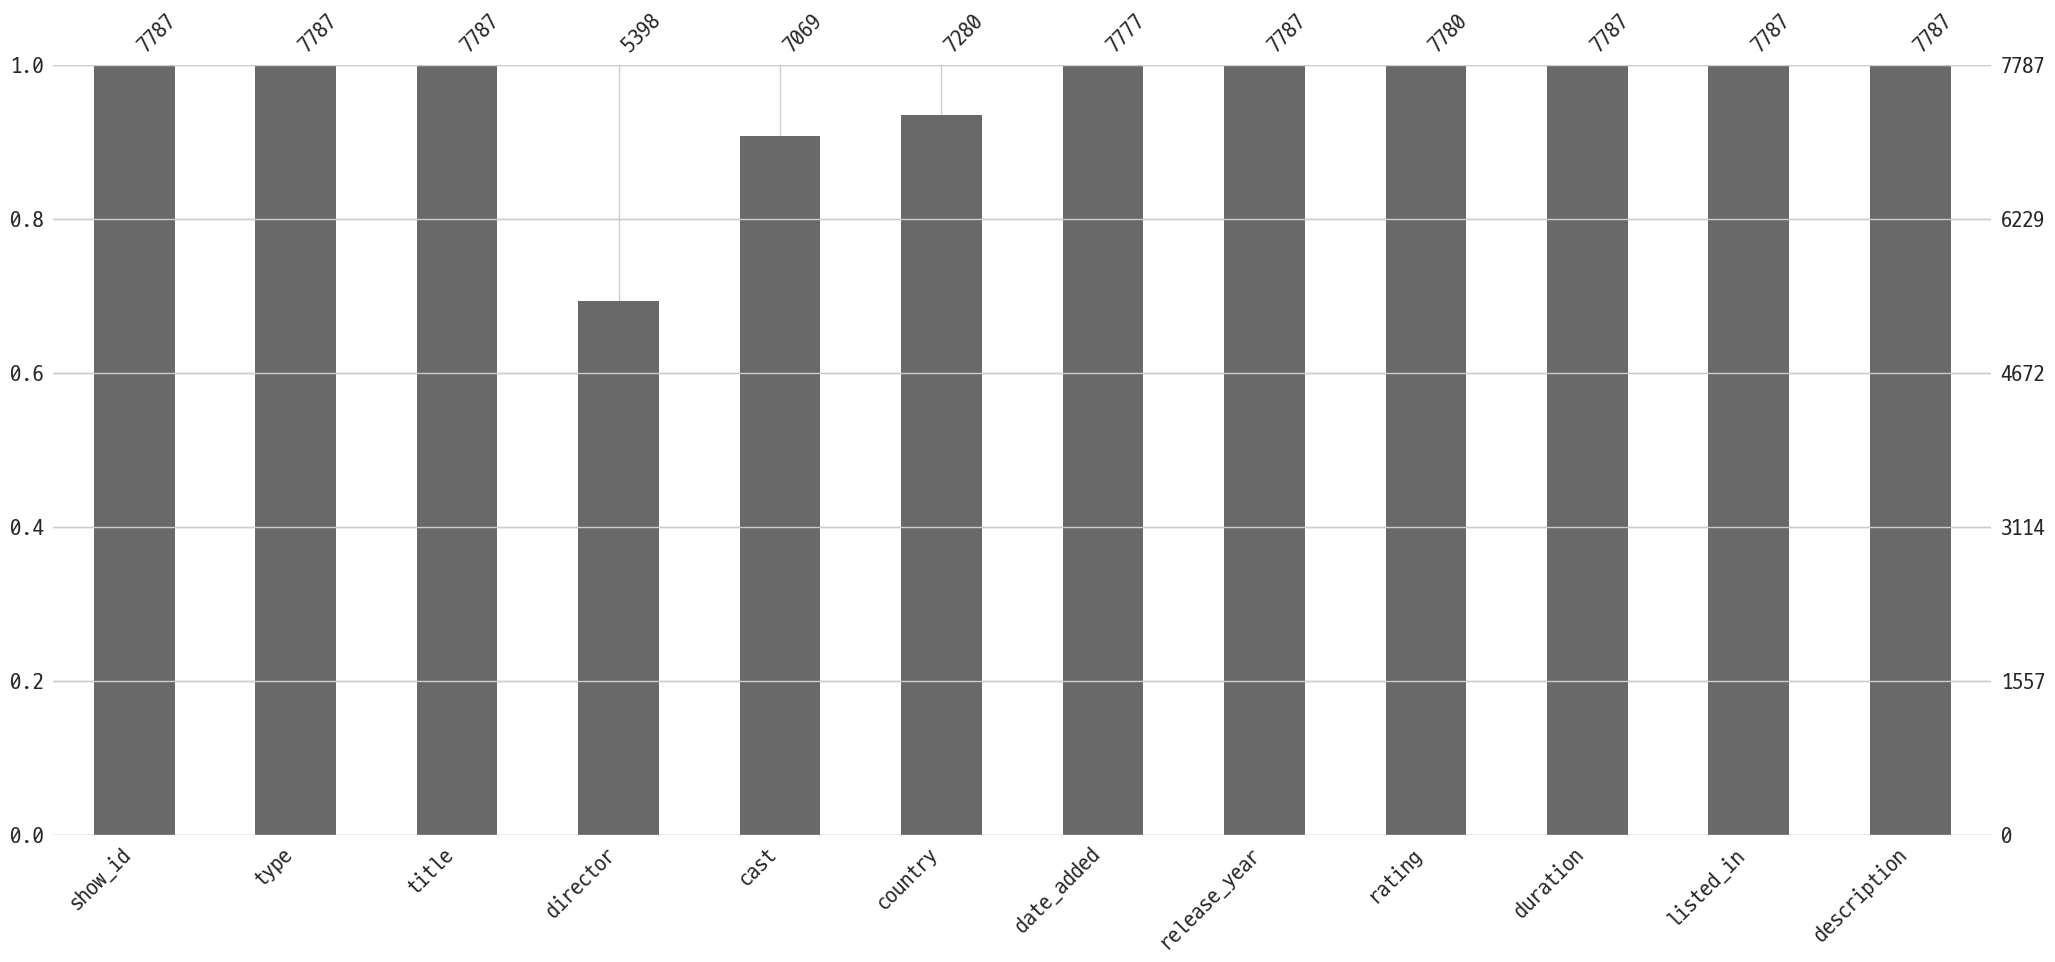

In [6]:
msno.bar(df)

<Axes: >

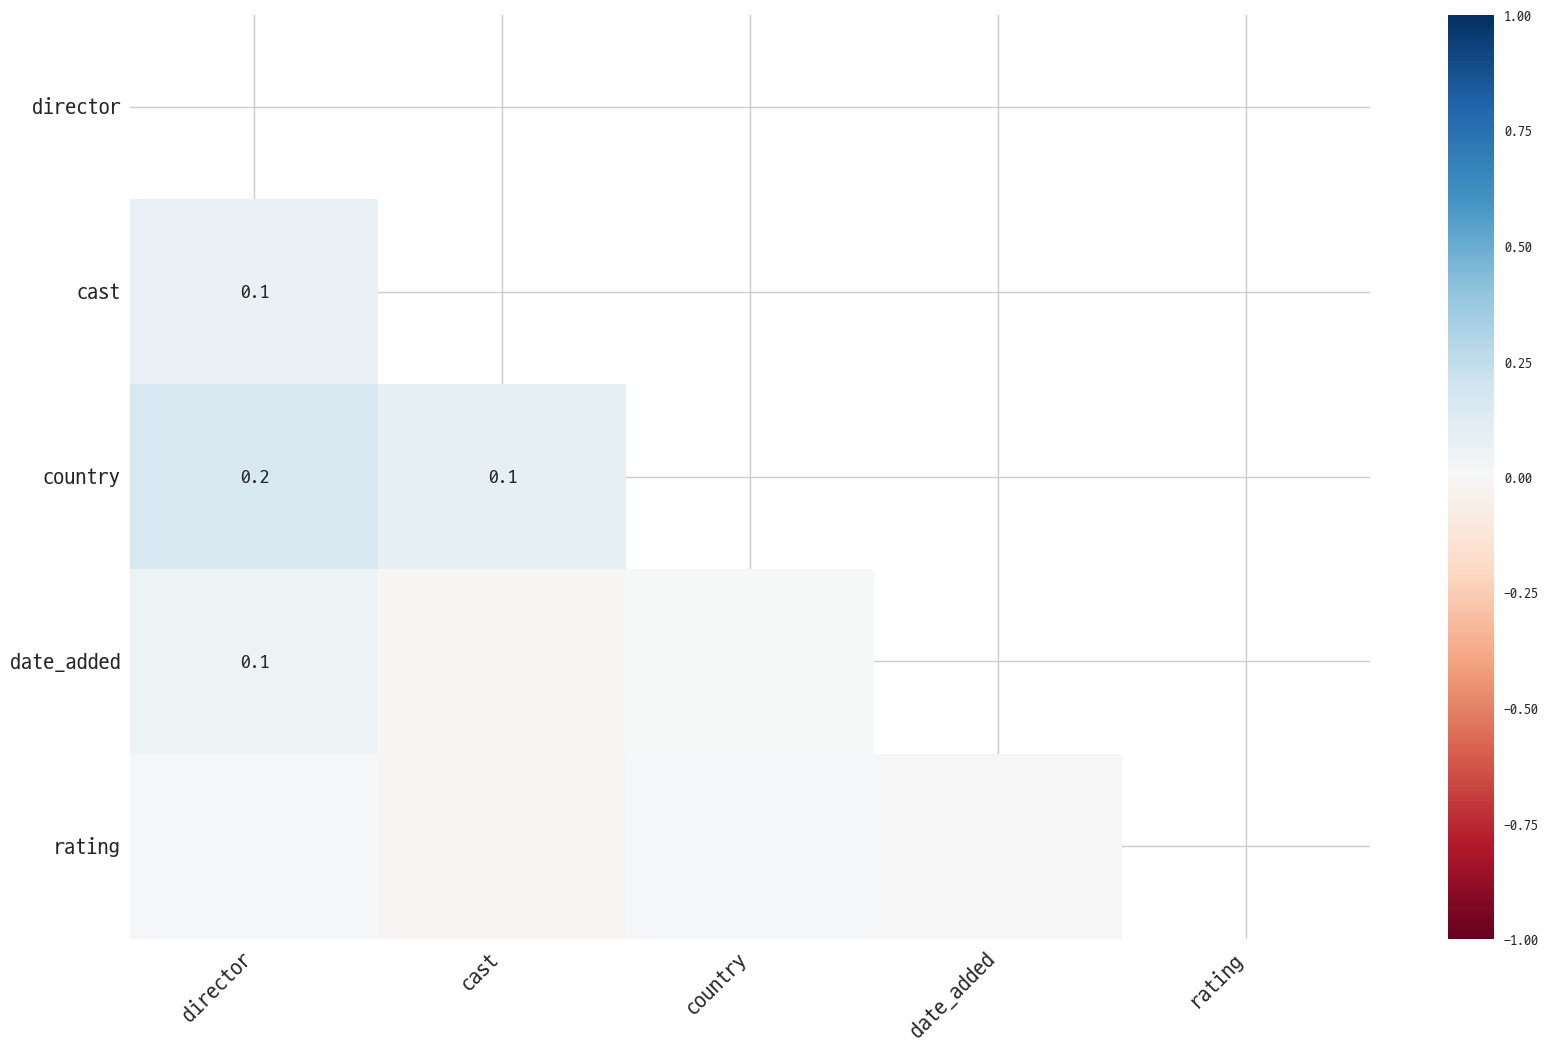

In [7]:
msno.heatmap(df)

In [8]:
df.isna().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [15]:
df['country'].mode()    # 최빈값 구하기

0    United States
Name: country, dtype: object

In [16]:
# 결측치를 해당 열의 최빈값(mode)으로 대체
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7787 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [19]:
# 'cast' 결측치를 'Missing'으로 대체하고 원본 데이터 수정
df['cast'].replace(np.nan, 'Missing', inplace  = True)
# df['cast'].fillna('Missing', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7787 non-null   object
 5   country       7787 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [21]:
df['director'] = df['director'].fillna('Missing')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      7787 non-null   object
 4   cast          7787 non-null   object
 5   country       7787 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
# 결측치를 포함하하는 행 삭제 후 원본에 바로 적용
df.dropna(inplace=True) # axis=0은 기본 적용

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7770 non-null   object
 1   type          7770 non-null   object
 2   title         7770 non-null   object
 3   director      7770 non-null   object
 4   cast          7770 non-null   object
 5   country       7770 non-null   object
 6   date_added    7770 non-null   object
 7   release_year  7770 non-null   int64 
 8   rating        7770 non-null   object
 9   duration      7770 non-null   object
 10  listed_in     7770 non-null   object
 11  description   7770 non-null   object
dtypes: int64(1), object(11)
memory usage: 789.1+ KB


In [24]:
#중복 행 삭제
df.drop_duplicates(inplace=True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7770 non-null   object
 1   type          7770 non-null   object
 2   title         7770 non-null   object
 3   director      7770 non-null   object
 4   cast          7770 non-null   object
 5   country       7770 non-null   object
 6   date_added    7770 non-null   object
 7   release_year  7770 non-null   int64 
 8   rating        7770 non-null   object
 9   duration      7770 non-null   object
 10  listed_in     7770 non-null   object
 11  description   7770 non-null   object
dtypes: int64(1), object(11)
memory usage: 789.1+ KB


In [ ]:
# date_added 타입을 날자형으로 변경
# errors='coerce' : 변환할 수 없는 값을 결측값으로 처리

df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7682 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 789.1+ KB


In [28]:
df['month_added'] = df['date_added'].dt.month
df['month_name_added'] = df['date_added'].dt.month_name()
df['year_added'] = df['date_added'].dt.year

df.tail(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added
7785,s7786,TV Show,Zumbo's Just Desserts,Missing,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,10.0,October,2020.0
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,Missing,"United Kingdom, Canada, United States",2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,3.0,March,2020.0


In [ ]:
# country가 여러값이 있는 경우에는 가장 첫 값만 선택
df['country_1'] = df['country'].str.split(',').str[0]
df['country_1'].tail(2)

7785         Australia
7786    United Kingdom
Name: country_1, dtype: object

In [30]:
df['country_1'].replace('United States', 'USA', inplace=True)
df['country_1'].replace('United Kingdom', 'UK', inplace=True)
df['country_1'].replace('South Korea', 'S.Korea', inplace=True)
df['country_1'].tail(2)

7785    Australia
7786           UK
Name: country_1, dtype: object

In [31]:
df['country_1'].unique()

array(['Brazil', 'Mexico', 'Singapore', 'USA', 'Turkey', 'Egypt', 'India',
       'Poland', 'Thailand', 'Nigeria', 'Norway', 'UK', 'Japan',
       'S.Korea', 'Italy', 'Canada', 'Indonesia', 'Romania', 'Spain',
       'Iceland', 'South Africa', 'France', 'Portugal', 'Hong Kong',
       'Argentina', 'Germany', 'Denmark', 'Kenya', 'New Zealand',
       'Pakistan', 'Australia', 'China', 'Taiwan', 'Netherlands',
       'Philippines', 'United Arab Emirates', 'Iran', 'Israel', 'Uruguay',
       'Bulgaria', 'Mauritius', 'Lebanon', 'Colombia', 'Soviet Union',
       'Sweden', 'Malaysia', 'Ireland', 'Serbia', 'Finland', 'Peru',
       'Chile', 'Ghana', 'Saudi Arabia', 'Namibia', 'Russia', 'Belgium',
       'Vietnam', 'Kuwait', 'Czech Republic', 'Zimbabwe', 'Hungary',
       'Venezuela', 'Cambodia', 'Austria', 'West Germany', 'Slovenia',
       'Switzerland', 'Jordan', 'Bangladesh', 'Georgia', 'Puerto Rico',
       'Senegal', 'Guatemala', 'Ukraine', 'Jamaica', 'Belarus', 'Cyprus',
       'Greece'

In [32]:
df['rating'].unique()

array(['TV-MA', 'R', 'PG-13', 'TV-14', 'TV-PG', 'NR', 'TV-G', 'TV-Y',
       'TV-Y7', 'PG', 'G', 'NC-17', 'TV-Y7-FV', 'UR'], dtype=object)

In [33]:
ratings_ages = {
    'TV-MA': 'Adults',
    'R': 'Adults',
    'PG-13': 'Teens',
    'TV-14': 'Teens',
    'TV-PG': 'Older Kids',
    'NR': 'Adults',
    'TV-G': 'Kids',
    'TV-Y': 'Kids',
    'TV-Y7': 'Older Kids',
    'PG': 'Older Kids',
    'G': 'Kids',
    'NC-17': 'Adults',
    'TV-Y7-FV': 'Older Kids',
    'UR': 'Adults'
}

In [34]:
df['target_user'] = df['rating'].replace(ratings_ages)
df['target_user'].unique()

array(['Adults', 'Teens', 'Older Kids', 'Kids'], dtype=object)

In [37]:
df['duration'].unique()[:10]

array(['4 Seasons', '93 min', '78 min', '80 min', '123 min', '1 Season',
       '95 min', '119 min', '118 min', '143 min'], dtype=object)

In [38]:
df['season_count'] = np.where(
    df['duration'].str.contains('Season'), "",  # 'Season'이 있으면 빈 문자열
    df['duration'].str.split(' ').str[0]        # 없으면 공백 기준 첫 번째 단어
)

df['season_count'].unique()

array(['', '93', '78', '80', '123', '95', '119', '118', '143', '103',
       '89', '91', '149', '144', '124', '87', '110', '128', '117', '100',
       '84', '99', '90', '102', '104', '105', '56', '125', '81', '97',
       '106', '107', '109', '44', '75', '101', '113', '114', '130', '94',
       '140', '135', '82', '70', '121', '92', '164', '53', '83', '116',
       '86', '120', '96', '126', '129', '77', '137', '148', '28', '122',
       '176', '85', '22', '68', '111', '29', '142', '168', '21', '59',
       '20', '98', '108', '76', '26', '156', '30', '57', '150', '133',
       '115', '154', '127', '146', '136', '88', '131', '24', '112', '74',
       '63', '38', '25', '174', '60', '153', '158', '151', '162', '54',
       '51', '69', '64', '147', '42', '79', '40', '45', '172', '10',
       '163', '55', '72', '61', '71', '160', '171', '48', '139', '157',
       '15', '65', '134', '161', '62', '186', '49', '73', '58', '165',
       '166', '138', '159', '141', '132', '52', '67', '34', '66', 

In [39]:
df['season_count'].replace('', np.nan, inplace=True)
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,country_1,target_user,season_count
0,s1,TV Show,3%,Missing,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,8.0,August,2020.0,Brazil,Adults,NaN
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,12.0,December,2016.0,Mexico,Adults,93


In [42]:
df['genre'] = df['listed_in'].str.replace(' ,', ',', regex=False)\
                             .str.replace(', ', ',', regex=False)\
                             .str.split(',')
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,country_1,target_user,season_count,genre
0,s1,TV Show,3%,Missing,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,8.0,August,2020.0,Brazil,Adults,NaN,"[International TV Shows, TV Dramas, TV Sci-Fi ..."
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,12.0,December,2016.0,Mexico,Adults,93,"[Dramas, International Movies]"


In [43]:
df['type'] = pd.Categorical(df['type'])
df['type']

0       TV Show
1         Movie
2         Movie
3         Movie
4         Movie
         ...   
7782      Movie
7783      Movie
7784      Movie
7785    TV Show
7786      Movie
Name: type, Length: 7770, dtype: category
Categories (2, object): ['Movie', 'TV Show']

In [45]:
df['target_user'] = pd.Categorical(df['target_user'])
df['target_user']

0           Adults
1           Adults
2           Adults
3            Teens
4            Teens
           ...    
7782        Adults
7783         Teens
7784        Adults
7785    Older Kids
7786        Adults
Name: target_user, Length: 7770, dtype: category
Categories (4, object): ['Adults', 'Kids', 'Older Kids', 'Teens']

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           7770 non-null   object        
 1   type              7770 non-null   category      
 2   title             7770 non-null   object        
 3   director          7770 non-null   object        
 4   cast              7770 non-null   object        
 5   country           7770 non-null   object        
 6   date_added        7682 non-null   datetime64[ns]
 7   release_year      7770 non-null   int64         
 8   rating            7770 non-null   object        
 9   duration          7770 non-null   object        
 10  listed_in         7770 non-null   object        
 11  description       7770 non-null   object        
 12  month_added       7682 non-null   float64       
 13  month_name_added  7682 non-null   object        
 14  year_added        7682 non-nu

In [48]:
df['season_count'] = pd.to_numeric(df['season_count'])  ## 숫자 형식으로 변경
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,country_1,target_user,season_count,genre
0,s1,TV Show,3%,Missing,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,8.0,August,2020.0,Brazil,Adults,NaN,"[International TV Shows, TV Dramas, TV Sci-Fi ..."
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,12.0,December,2016.0,Mexico,Adults,93.0,"[Dramas, International Movies]"


In [49]:
df_tv = df[df['type'] == 'TV Show']
df_tv.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,country_1,target_user,season_count,genre
0,s1,TV Show,3%,Missing,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,8.0,August,2020.0,Brazil,Adults,NaN,"[International TV Shows, TV Dramas, TV Sci-Fi ..."
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,7.0,July,2017.0,Turkey,Adults,NaN,"[International TV Shows, TV Dramas, TV Mysteries]"


In [50]:
df_movie = df[df['type'] == 'Movie']
df_movie.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,country_1,target_user,season_count,genre
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,12.0,December,2016.0,Mexico,Adults,93.0,"[Dramas, International Movies]"
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",12.0,December,2018.0,Singapore,Adults,78.0,"[Horror Movies, International Movies]"


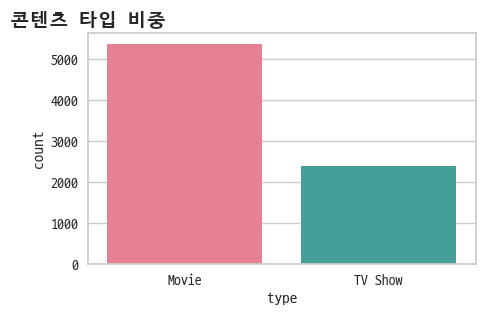

In [51]:
plt.figure(figsize=(5,3))
sns.countplot(x='type', data=df, palette='husl')
plt.title('콘텐츠 타입 비중', fontsize=14,fontweight='bold', position=(0, 0))
plt.show()

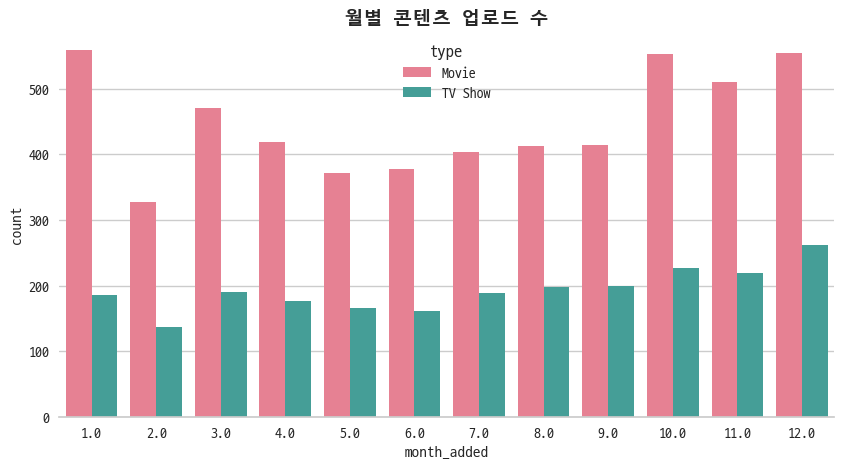

In [52]:
plt.figure(figsize=(10,5))
sns.countplot(x='month_added', hue='type', data=df, palette='husl')
sns.despine(left=True)  # 그래프의 테두리 삭제
plt.title('월별 콘텐츠 업로드 수', fontsize=14, fontweight='bold')
plt.show()

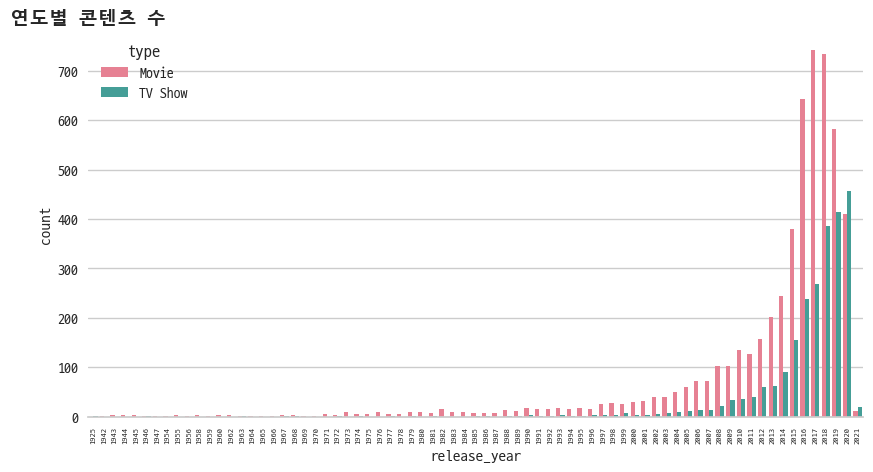

In [53]:
plt.figure(figsize=(10,5))
sns.countplot(x='release_year', hue='type', data=df, palette='husl')
sns.despine(left=True)  # 그래프의 테두리 삭제
plt.title('연도별 콘텐츠 수', fontsize=14, fontweight='bold', position=(0,0))
plt.xticks(rotation=90, fontsize=6)
plt.show()

In [54]:
top10_country = df.groupby('country_1')['country'].agg('count').sort_values(ascending=False)[:10]
top10_country

country_1
USA          3379
India         956
UK            576
Canada        259
Japan         235
France        196
S.Korea       194
Spain         168
Mexico        123
Australia     106
Name: country, dtype: int64

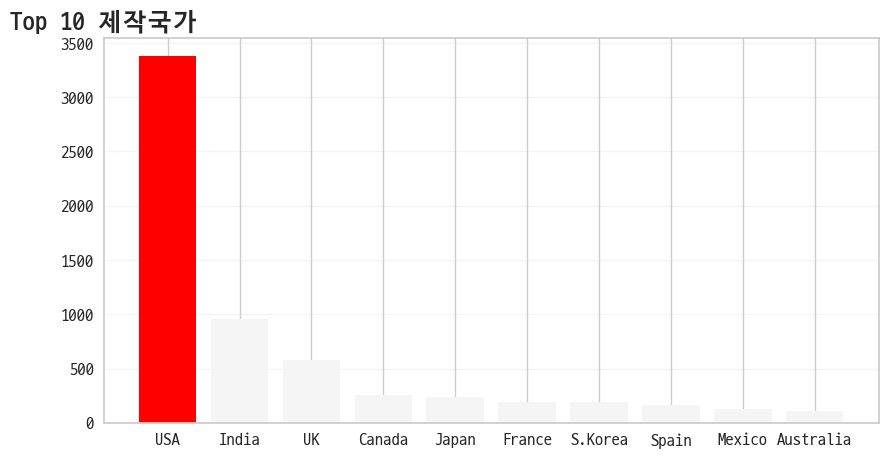

In [56]:
# Top1 컬러만 다르게하기 위한 컬러셋 변수 생성
colors = ['whitesmoke' for _ in range(len(top10_country))]
colors[0] =  'red'

plt.figure(figsize=(10,5))
plt.bar(top10_country.index, top10_country, width=0.8, linewidth=0.6, color=colors)
plt.grid(axis='y', linestyle='-', alpha=0.2)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.title('Top 10 제작국가', fontsize=18, fontweight='bold', position=(0, 0))
plt.show()

In [61]:
df_movie['listed_in']

1                            Dramas, International Movies
2                     Horror Movies, International Movies
3       Action & Adventure, Independent Movies, Sci-Fi...
4                                                  Dramas
6                     Horror Movies, International Movies
                              ...                        
7781                   Children & Family Movies, Comedies
7782                         Dramas, International Movies
7783       Dramas, International Movies, Music & Musicals
7784    Documentaries, International Movies, Music & M...
7786                      Documentaries, Music & Musicals
Name: listed_in, Length: 5372, dtype: object

In [ ]:
text = ', '.join(df_movie['listed_in'])  ## 컴마로 연결
text

'Dramas, International Movies, Horror Movies, International Movies, Action & Adventure, Independent Movies, Sci-Fi & Fantasy, Dramas, Horror Movies, International Movies, Dramas, Horror Movies, International Movies, Horror Movies, International Movies, Thrillers, Dramas, Thrillers, Documentaries, International Movies, Sports Movies, Independent Movies, Sci-Fi & Fantasy, Thrillers, Dramas, International Movies, Thrillers, Dramas, Thrillers, Comedies, Dramas, Independent Movies, Sports Movies, Dramas, Independent Movies, International Movies, Action & Adventure, Dramas, International Movies, Dramas, International Movies, Dramas, International Movies, Documentaries, Horror Movies, International Movies, Thrillers, Documentaries, International Movies, Documentaries, International Movies, Dramas, International Movies, Romantic Movies, Dramas, International Movies, Romantic Movies, Comedies, Comedies, Romantic Movies, Documentaries, Sports Movies, Comedies, Dramas, International Movies, Comed

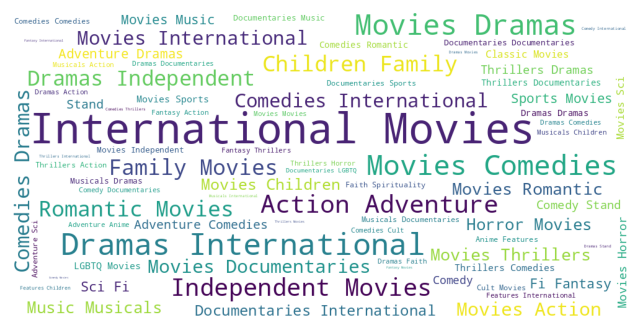

In [65]:
wordcloud = WordCloud(background_color='white', width=1000,  height=500, max_words=80, margin=10, random_state=1).generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [66]:
df_movie['cast']

1       Demián Bichir, Héctor Bonilla, Oscar Serrano, ...
2       Tedd Chan, Stella Chung, Henley Hii, Lawrence ...
3       Elijah Wood, John C. Reilly, Jennifer Connelly...
4       Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...
6       Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...
                              ...                        
7781    Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...
7782    Imad Creidi, Antoinette Turk, Elias Gergi, Car...
7783    Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
7784                                              Nasty C
7786                                              Missing
Name: cast, Length: 5372, dtype: object

In [67]:
text2 = ', '.join(df_movie['cast'])
text2

'Demián Bichir, Héctor Bonilla, Oscar Serrano, Azalia Ortiz, Octavio Michel, Carmen Beato, Tedd Chan, Stella Chung, Henley Hii, Lawrence Koh, Tommy Kuan, Josh Lai, Mark Lee, Susan Leong, Benjamin Lim, Elijah Wood, John C. Reilly, Jennifer Connelly, Christopher Plummer, Crispin Glover, Martin Landau, Fred Tatasciore, Alan Oppenheimer, Tom Kane, Jim Sturgess, Kevin Spacey, Kate Bosworth, Aaron Yoo, Liza Lapira, Jacob Pitts, Laurence Fishburne, Jack McGee, Josh Gad, Sam Golzari, Helen Carey, Jack Gilpin, Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed El Fishawy, Mahmoud Hijazi, Jihane Khalil, Asmaa Galal, Tara Emad, Samuel L. Jackson, John Heard, Kelly Rowan, Clifton Collins Jr., Tony Plana, Divya Dutta, Atul Kulkarni, Mohan Agashe, Anupam Shyam, Raayo S. Bakhirta, Yashvit Sancheti, Greeva Kansara, Archan Trivedi, Rajiv Pathak, Rajneesh Duggal, Adah Sharma, Indraneil Sengupta, Anjori Alagh, Rajendranath Zutshi, Vipin Sharma, Amin Hajee, Shri Vallabh Vyas, Thomas Jane, Molly Parker, Dylan 

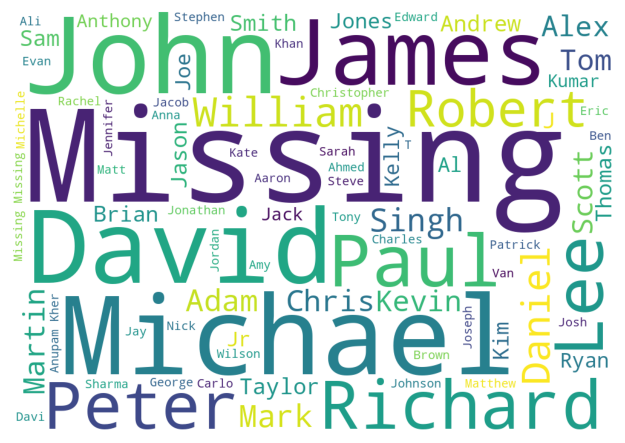

In [68]:
wordcloud = WordCloud(background_color='white', width=1000,  height=700, max_words=80, margin=10, random_state=1).generate(text2)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

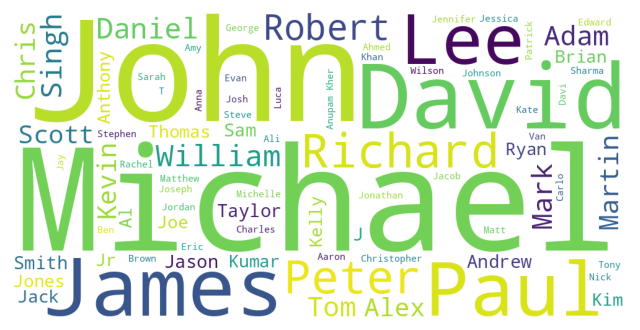

In [69]:
text2 = ','.join(df_movie.loc[df_movie['cast'] !="Missing", 'cast'])
wordcloud = WordCloud(background_color='white', width=1000,  height=500, max_words=80, margin=10, random_state=1).generate(text2)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()